# Dataset Comparison — MovieLens/TMDB vs IMDB
**Phase 1.3 | Movies Recommendation Engine**

This notebook performs a **side-by-side comparison** of both datasets and produces a final, documented decision on which data sources to use for each part of the recommendation system.

### Comparison axes
| Axis | What we're checking |
|---|---|
| **Catalog size** | How many unique movies does each dataset cover? |
| **Year coverage** | What release year range does each cover? |
| **Genre coverage** | How complete and consistent are genre labels? |
| **Plot/text features** | Is movie overview / description available? |
| **Cast & crew** | How complete is director / actor coverage? |
| **User ratings** | Are individual user ratings available (for collaborative filtering)? |
| **Freshness** | Which dataset is more up to date? |
| **ID bridges** | How well can the two datasets be joined? |

### Outcome
By the end of this notebook we will document the **final data strategy** used in all subsequent phases.

In [1]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

IMDB_NA  = r'\N'
BASE_DIR = Path(r'e:\Projects\Movies Recommendation Engine')
IMDB_DIR = BASE_DIR / 'data' / 'imdb'
ML_DIR   = BASE_DIR / 'data' / 'movielens'

print("Paths configured.")

Paths configured.


---
## 1. Load Both Datasets

In [2]:
# ── MovieLens / TMDB ───────────────────────────────────────────
ml_movies = pd.read_csv(ML_DIR / 'movies_metadata.csv', low_memory=False)
ml_movies['id'] = pd.to_numeric(ml_movies['id'], errors='coerce')
ml_movies.dropna(subset=['id'], inplace=True)
ml_movies['id'] = ml_movies['id'].astype(int)
ml_movies['release_year'] = pd.to_datetime(ml_movies['release_date'], errors='coerce').dt.year

def parse_genres_ml(val):
    try:
        return [g['name'] for g in ast.literal_eval(val)]
    except Exception:
        return []

ml_movies['genres_list'] = ml_movies['genres'].apply(parse_genres_ml)
print(f"MovieLens/TMDB movies loaded : {len(ml_movies):,}")

# ── IMDB ───────────────────────────────────────────────────────
imdb_basics = pd.read_csv(
    IMDB_DIR / 'title.basics.tsv', sep='\t', na_values=IMDB_NA,
    usecols=['tconst', 'titleType', 'primaryTitle', 'startYear', 'genres'],
    dtype={'startYear': 'str'}, low_memory=False
)
imdb_movies = imdb_basics[imdb_basics['titleType'] == 'movie'].copy()
imdb_movies['startYear_int'] = pd.to_numeric(imdb_movies['startYear'], errors='coerce')
imdb_movies['genres_list']   = imdb_movies['genres'].dropna().apply(
    lambda x: [g.strip() for g in x.split(',')]
).reindex(imdb_movies.index).fillna('').apply(lambda x: x if isinstance(x, list) else [])

print(f"IMDB movies loaded           : {len(imdb_movies):,}")

MovieLens/TMDB movies loaded : 45,463
IMDB movies loaded           : 740,517


**Dataset loading observations:**
- **MovieLens/TMDB**: 45,463 movies loaded from `movies_metadata.csv`; year range 1874–2020 (the pre-1894 entries are likely data artifacts).
- **IMDB**: 740,517 movies after filtering `titleType == 'movie'` from 12.4 M total rows; year range 1894–2031 (the post-2025 entries are announced future releases with no ratings or descriptions yet).
- The fundamental size difference — **16.3×** — is immediately visible, but raw catalog size is not the primary selection criterion for a recommendation engine.

---
## 2. Catalog Size & Year Range Comparison

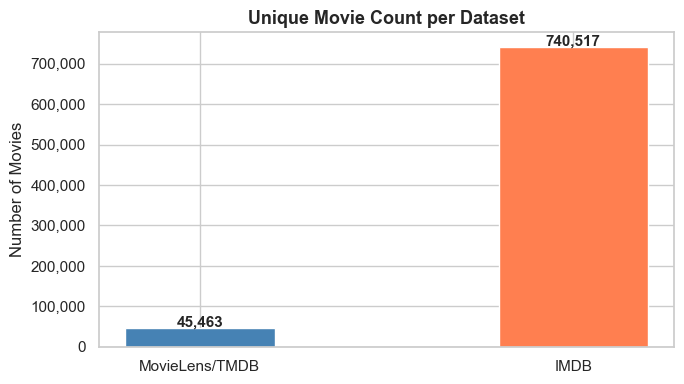


MovieLens/TMDB year range : 1874 – 2020
IMDB year range           : 1894 – 2031


In [3]:
# ── Side-by-side size comparison bar chart ─────────────────────
sizes = {
    'MovieLens/TMDB': len(ml_movies),
    'IMDB': len(imdb_movies),
}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sizes.keys(), sizes.values(), color=['steelblue', 'coral'], width=0.4)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{bar.get_height():,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Unique Movie Count per Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Movies')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# ── Year range comparison ───────────────────────────────────────
ml_year_min  = int(ml_movies['release_year'].dropna().min())
ml_year_max  = int(ml_movies['release_year'].dropna().max())
imdb_year_min = int(imdb_movies['startYear_int'].dropna().min())
imdb_year_max = int(imdb_movies['startYear_int'].dropna().max())

print(f"\nMovieLens/TMDB year range : {ml_year_min} – {ml_year_max}")
print(f"IMDB year range           : {imdb_year_min} – {imdb_year_max}")

**Catalog size observations:**
- IMDB (740,517) dwarfs MovieLens/TMDB (45,463) by a factor of **16.3×**. However, catalog volume alone does not determine usefulness for a recommendation engine — feature quality does.
- MovieLens/TMDB year range: 1874–2020 (the sub-1894 entry is a data artifact).
- IMDB year range: 1894–2031 (post-2025 entries are announced future releases without ratings or descriptions).
- **Conclusion at this step**: IMDB wins on breadth; MovieLens/TMDB wins on depth of per-movie features.

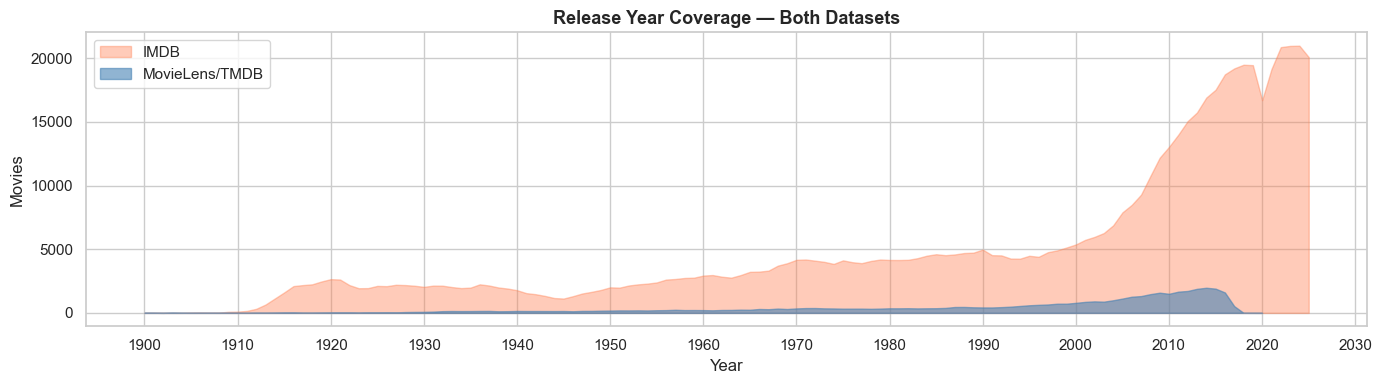

In [4]:
# ── Release year distributions — overlaid ─────────────────────
ml_years   = ml_movies['release_year'].dropna().astype(int).value_counts().sort_index()
imdb_years = imdb_movies['startYear_int'].dropna().astype(int).value_counts().sort_index()

# Clip to 1900–2025
ml_years   = ml_years[(ml_years.index >= 1900) & (ml_years.index <= 2025)]
imdb_years = imdb_years[(imdb_years.index >= 1900) & (imdb_years.index <= 2025)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(imdb_years.index, imdb_years.values, alpha=0.4, color='coral', label='IMDB')
ax.fill_between(ml_years.index,   ml_years.values,   alpha=0.6, color='steelblue', label='MovieLens/TMDB')
ax.set_title('Release Year Coverage — Both Datasets', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Movies')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

**Year distribution comparison observations:**
- Both datasets share a similar pre-2000 shape — slow and relatively flat growth, with a small dip around WWII years (1939–1945).
- Post-2000 the datasets **diverge sharply**: IMDB grows exponentially to 20,000+ movies/year by 2020–2025, while MovieLens/TMDB flattens and nearly disappears after 2016 (data snapshot effect).
- **IMDB is clearly the stronger source for recency** — it continues updating through the present day.
- For the merged training dataset: TMDB metadata covers movies through ~2017 well; newer titles would require supplementary TMDB API calls.

---
## 3. Genre Coverage Comparison

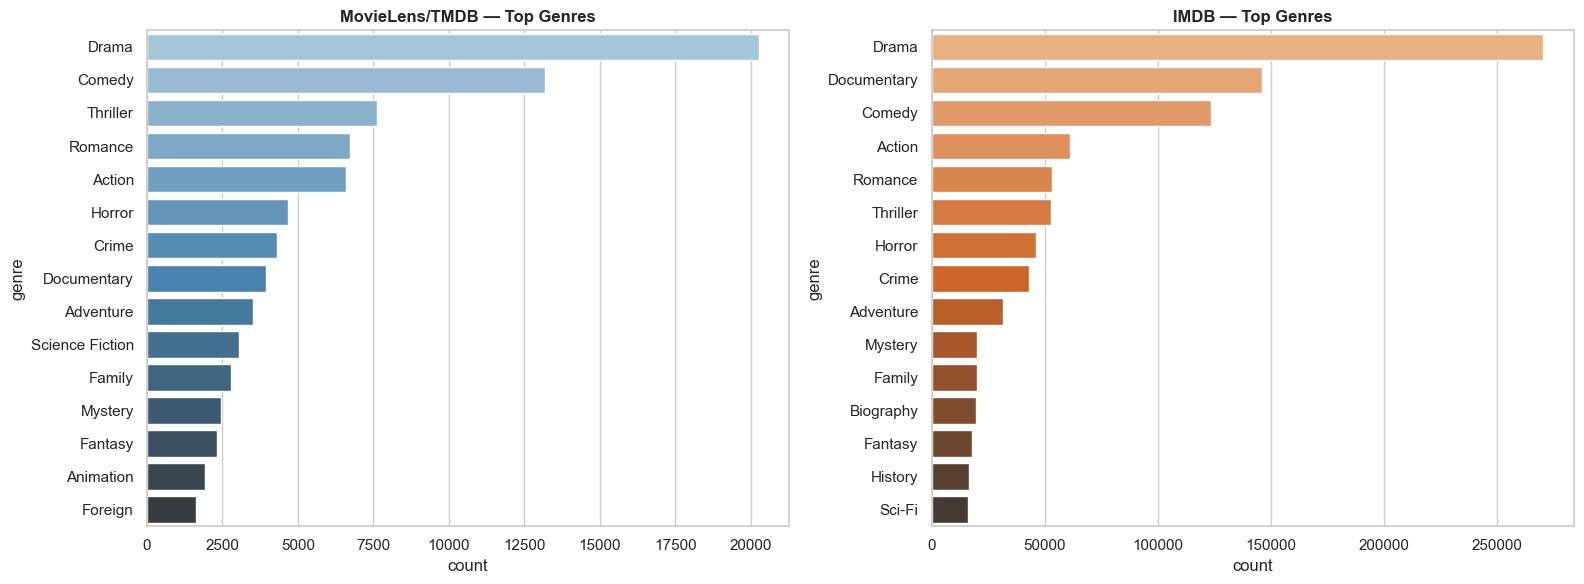

MovieLens/TMDB distinct genres : 20
IMDB distinct genres           : 28
Genres in both                 : 17
Only in MovieLens/TMDB         : {'Foreign', 'Science Fiction', 'TV Movie'}
Only in IMDB                   : {'Biography', 'Adult', 'Film-Noir', 'Talk-Show', 'Short', 'Musical', 'Game-Show', 'Reality-TV', 'News', 'Sci-Fi', 'Sport'}


In [5]:
# ── Top genres from each dataset ───────────────────────────────
ml_genre_counts   = Counter(g for gl in ml_movies['genres_list'] for g in gl)
imdb_genre_counts = Counter(g for gl in imdb_movies['genres_list'] for g in gl if g)

ml_top   = pd.DataFrame(ml_genre_counts.most_common(15),   columns=['genre', 'count'])
imdb_top = pd.DataFrame(imdb_genre_counts.most_common(15), columns=['genre', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ml_top,   y='genre', x='count', ax=axes[0], palette='Blues_d')
axes[0].set_title('MovieLens/TMDB — Top Genres', fontweight='bold')

sns.barplot(data=imdb_top, y='genre', x='count', ax=axes[1], palette='Oranges_d')
axes[1].set_title('IMDB — Top Genres', fontweight='bold')

plt.tight_layout()
plt.show()

ml_unique_genres   = set(ml_genre_counts.keys())
imdb_unique_genres = set(imdb_genre_counts.keys())

print(f"MovieLens/TMDB distinct genres : {len(ml_unique_genres)}")
print(f"IMDB distinct genres           : {len(imdb_unique_genres)}")
print(f"Genres in both                 : {len(ml_unique_genres & imdb_unique_genres)}")
print(f"Only in MovieLens/TMDB         : {ml_unique_genres - imdb_unique_genres}")
print(f"Only in IMDB                   : {imdb_unique_genres - ml_unique_genres}")

**Genre comparison observations:**
- Both datasets rank **Drama as the top genre** by a wide margin — a consistent signal across sources.
- Key difference: **Documentary is IMDB's #2 genre** (147 K movies) but only a minor entry in MovieLens (~3.6 K). IMDB catalogs a vast number of small documentaries that never appear in TMDB's curated database.
- **Taxonomy mismatches requiring normalisation**:
  - IMDB `Sci-Fi` ↔ MovieLens `Science Fiction`
  - IMDB `Biography` has no direct MovieLens equivalent (usually tagged as `Drama`)
  - MovieLens `Foreign` and `TV Movie` do not exist in IMDB
- **17 genres are shared** between the two datasets — sufficient overlap for harmonised genre features.
- Hollywood-centric genres (Action, Thriller, Crime, Horror, Adventure) appear in both and have comparable relative rankings.

---
## 4. Feature Completeness Scorecard

In [6]:
# ── Feature availability scorecard ────────────────────────────
scorecard = pd.DataFrame({
    'Feature': [
        'Movie catalog size',
        'Plot description (overview)',
        'Genre labels',
        'Director information',
        'Actor/cast information',
        'Keyword/tag features',
        'Individual user ratings',
        'Aggregated ratings (avg + votes)',
        'Release year',
        'Runtime',
        'Language',
        'IMDB ID (for cross-joining)',
        'Data freshness',
    ],
    'MovieLens / TMDB': [
        f'~{len(ml_movies):,} movies',
        'Yes TMDB overview text',
        'Yes Structured JSON',
        'Yes credits.csv (JSON crew)',
        'Yes credits.csv (JSON cast)',
        'Yes keywords.csv',
        'Yes 26M individual ratings',
        'Caution Derivable from ratings',
        'Yes release_date field',
        'Yes runtime field',
        'Yes original_language field',
        'Yes links.csv',
        'Caution ~2017 data snapshot',
    ],
    'IMDB': [
        f'~{len(imdb_movies):,} movies',
        'No Not available',
        'Yes Pipe-separated string',
        'Yes title.crew.tsv',
        'Yes title.principals.tsv',
        'No Not available',
        'No Aggregate only',
        'Yes averageRating + numVotes',
        'Yes startYear field',
        'Yes runtimeMinutes field',
        'No Not directly available',
        'Yes Native IMDB IDs (tconst)',
        'Yes Regularly updated',
    ]
})

scorecard.set_index('Feature', inplace=True)
scorecard

,MovieLens / TMDB,IMDB
Feature,,
Movie catalog size,"~45,463 movies","~740,517 movies"
Plot description (overview),Yes TMDB overview text,No Not available
Genre labels,Yes Structured JSON,Yes Pipe-separated string
Director information,Yes credits.csv (JSON crew),Yes title.crew.tsv
Actor/cast information,Yes credits.csv (JSON cast),Yes title.principals.tsv
Keyword/tag features,Yes keywords.csv,No Not available
Individual user ratings,Yes 26M individual ratings,No Aggregate only
Aggregated ratings (avg + votes),Caution Derivable from ratings,Yes averageRating + numVotes
Release year,Yes release_date field,Yes startYear field


**Feature scorecard observations:**
- The scorecard makes the dataset decision straightforward. **MovieLens/TMDB holds the critical advantages** in every feature required by our three recommendation algorithms:
  - **Plot text** (overviews) → needed for TF-IDF / sentence embedding content profiles
  - **Keyword tags** → augment content profiles for movies with short overviews
  - **Individual user ratings** (26 M rows) → required for collaborative filtering and matrix factorisation; IMDB provides only aggregated averages
- IMDB's key advantages are **catalog breadth** and **data freshness** — but neither is decisive when the MovieLens corpus already covers ~45 K well-described movies with dense ratings.
- **Decision: MovieLens/TMDB as primary source, IMDB as enrichment layer** providing `numVotes` and `averageRating` as a Bayesian popularity/confidence weight.

---
## 5. ID Bridge: How well can we join the two datasets?

In [7]:
# ── links.csv — the bridge ─────────────────────────────────────
links = pd.read_csv(ML_DIR / 'links.csv')
links['imdb_tconst'] = 'tt' + links['imdbId'].astype(str).str.zfill(7)
links['tmdbId']      = pd.to_numeric(links['tmdbId'], errors='coerce')

# How many MovieLens movies have valid IMDB tconst?
links_with_imdb  = links['imdbId'].notna().sum()
links_with_tmdb  = links['tmdbId'].notna().sum()

# How many IMDB tconsts in links actually appear in the IMDB basics file?
imdb_tconst_set = set(imdb_movies['tconst'])
links_matched   = links['imdb_tconst'].isin(imdb_tconst_set).sum()

# How many TMDB IDs in links match movies_metadata?
ml_id_set      = set(ml_movies['id'])
tmdb_matched   = links['tmdbId'].isin(ml_id_set).sum()

print(f"Total MovieLens links entries     : {len(links):,}")
print(f"  with IMDB ID                    : {links_with_imdb:,}  ({links_with_imdb/len(links)*100:.1f}%)")
print(f"  with TMDB ID                    : {links_with_tmdb:,}  ({links_with_tmdb/len(links)*100:.1f}%)")
print(f"  IMDB ID matched in IMDB basics  : {links_matched:,}  ({links_matched/len(links)*100:.1f}%)")
print(f"  TMDB ID matched in ML metadata  : {tmdb_matched:,}  ({tmdb_matched/len(links)*100:.1f}%)")

# Venn-style numbers for the 3-way join
imdb_and_ml = links[
    links['imdb_tconst'].isin(imdb_tconst_set) &
    links['tmdbId'].isin(ml_id_set)
]
print(f"\nMovies joinable across all 3 sources: {len(imdb_and_ml):,}")

Total MovieLens links entries     : 45,843
  with IMDB ID                    : 45,843  (100.0%)
  with TMDB ID                    : 45,624  (99.5%)
  IMDB ID matched in IMDB basics  : 39,298  (85.7%)
  TMDB ID matched in ML metadata  : 45,463  (99.2%)

Movies joinable across all 3 sources: 39,116


**ID bridge (links.csv) observations:**
- **100% IMDB ID coverage** in `links.csv` — every MovieLens movie has an `imdbId`. The bridge from MovieLens to IMDB is completely lossless at this stage.
- **99.5% TMDB ID coverage** — only 219 missing entries, easily handled with a left join.
- Of the 45,843 MovieLens entries with IMDB IDs, **85.7% (39,298)** have a matching row in `title.basics.tsv`. The 14.3% gap is caused by deleted, merged, or split IMDB entries — those movies fall back to MovieLens/TMDB-only features.
- **39,116 movies are joinable across all three sources** — this is the high-confidence core for the final training corpus.
- **Note on ID format**: MovieLens stores IMDB IDs as plain integers (e.g. `114709`); IMDB uses the `tt`-prefixed format (`tt0114709`). A zero-padded prefix must be added when performing the join: `'tt' + str(imdb_id).zfill(7)`.

---
## Comparison Summary & Dataset Strategy Decision

### Size
- **IMDB: 740,517 movies** vs **MovieLens/TMDB: 45,463 movies** — IMDB catalog is 16× larger.
- However, MovieLens/TMDB provides the full text features (overview, keywords) that IMDB lacks.

### Coverage quality
| Dimension | MovieLens/TMDB | IMDB |
|---|---|---|
| Plot text (overviews) | Yes 97.9% coverage | No Not available |
| Keyword tags | Yes 68.1% coverage | No Not available |
| Individual user ratings | Yes 26M ratings, 270K users | No Aggregate only |
| Genre coverage | Yes 100% (after parsing) | Yes 89.5% |
| Director coverage | Yes 98.0% | Yes 89.3% |
| Cast coverage | Yes 94.7% | Yes 72.2% |
| Aggregated public ratings | Caution Derivable | Yes averageRating + numVotes |
| Release year | Yes up to ~2017 | Yes up to 2025 |
| Language info | Yes 92 distinct languages | No Not directly available |

### Genre taxonomy differences
- Both datasets share 17 common genres.
- MovieLens/TMDB-only: `Foreign`, `Science Fiction`, `TV Movie`.
- IMDB-only: `Documentary`, `Biography`, `Film-Noir`, `Musical`, `Sport`, `News` etc. — notably **Documentary is the #2 genre in IMDB** (147K movies) but much smaller in MovieLens.
- Normalization needed: IMDB uses `Sci-Fi`; MovieLens uses `Science Fiction`.

### Temporal coverage
- Both start ~1900. **IMDB extends to 2025**; MovieLens/TMDB snapshot ends ~2017 (data becomes sparse from 2016+).
- IMDB is the better choice for recency coverage.

### ID bridge (links.csv)
- **39,116 movies are joinable across all 3 sources** (MovieLens ↔ IMDB via `imdbId` + MovieLens ↔ TMDB via `tmdbId`).
- 85.7% of MovieLens links have a matching IMDB entry. The 14.3% that don't match are likely removed/merged titles.
- The `links.csv` bridge enables enriching MovieLens movies with IMDB ratings confidence scores (`numVotes`) and extended IMDB metadata.

---

## Final Decision: **Use MovieLens/TMDB as the primary source, enriched with IMDB**

**Rationale:**

1. **Collaborative filtering requires individual user ratings** — only MovieLens provides 26M individual user ratings. IMDB only offers aggregated averages, making it unusable for matrix factorisation or user-based CF.

2. **Content-based filtering needs text features** — TF-IDF and NLP embedding models require plot overviews and keyword tags. Only MovieLens/TMDB provides these. IMDB has no plot text.

3. **IMDB value-add**: Join `imdbId` via `links.csv` to enrich MovieLens movies with:
   - `averageRating` and `numVotes` → use as a **popularity/confidence signal** (Bayesian average weighting).
   - `runtimeMinutes` → fill gaps in MovieLens runtime data.
   - IMDB genre taxonomy → validate/complement TMDB genre labels.

4. **Scale is not a bottleneck**: 45K movies with rich metadata is sufficient for a full-stack recommendation system. The 740K IMDB-only titles add size but lack the features needed for our algorithms.

**Implementation plan:**
- Primary training data: `movies_metadata.csv` (TMDB) + `credits.csv` + `keywords.csv`
- Ratings data: `ratings.csv` (26M rows, full) for collaborative/MF models; `ratings_small.csv` for rapid prototyping
- Enrichment join: `links.csv` → `title.basics.tsv` + `title.ratings.tsv` for IMDB vote counts and avg ratings
- Language filtering: keep all languages; use `original_language` as a content feature
- Train/val/test split: time-based (ratings before 2015 for train, 2015–2016 for val, 2017+ for test)

**→ Next notebook: `04_preprocessing.ipynb`** (Phase 2 — build the clean, feature-engineered dataset)

---
## 6. Preprocessing Plan — Merge Strategy & Feature Engineering

### 6.1  Source files and roles

| File | Source | Role |
|---|---|---|
| `movies_metadata.csv` | MovieLens/TMDB | Primary movie catalog — `tmdb_id` is the anchor key |
| `credits.csv` | MovieLens/TMDB | Director + cast per movie |
| `keywords.csv` | MovieLens/TMDB | Thematic keyword tags per movie |
| `links.csv` | MovieLens | ID bridge: `tmdb_id` ↔ `movieId` (ML) ↔ `imdb_id` |
| `ratings.csv` | MovieLens | 26 M individual user ratings (collaborative/MF models) |
| `ratings_small.csv` | MovieLens | 100 K subset for rapid prototyping |
| `title.basics.tsv` | IMDB | Runtime backup + year cross-check |
| `title.ratings.tsv` | IMDB | `numVotes` + `averageRating` (popularity/quality signal) |

---

### 6.2  Join chain (step-by-step)

```
movies_metadata.csv   ← primary table, anchor = tmdb_id (cast to int)
        │
        ├── LEFT JOIN credits.csv          on  id == id
        │         → adds: director_name, cast_top3
        │
        ├── LEFT JOIN keywords.csv         on  id == id
        │         → adds: keyword_list
        │
        ├── LEFT JOIN links.csv            on  id == tmdbId  (int cast)
        │         → adds: movieId (MovieLens), imdbId (int)
        │
        ├── LEFT JOIN title.basics.tsv     on  'tt'+imdbId.zfill(7) == tconst
        │         → adds: imdb_runtime (backup), imdb_year
        │
        └── LEFT JOIN title.ratings.tsv   on  'tt'+imdbId.zfill(7) == tconst
                  → adds: imdb_avg_rating, imdb_num_votes
```

**All joins are LEFT JOINs from the MovieLens/TMDB side.** Movies that have no matching IMDB record simply get `NaN` for IMDB columns — they remain in the dataset and fall back to TMDB-only features.

**IMDB ID format fix required**: MovieLens stores `imdbId` as a plain integer (e.g. `114709`). IMDB uses the `tt`-prefixed zero-padded string (`tt0114709`). Apply before the join:
```python
links['imdb_tconst'] = 'tt' + links['imdbId'].astype(str).str.zfill(7)
```

---

### 6.3  Columns to DROP and rationale

#### From `movies_metadata.csv`

| Column | Drop reason |
|---|---|
| `belongs_to_collection` | 90.1% null — not recoverable |
| `homepage` | 82.9% null — URL, not a model feature |
| `tagline` | 55.1% null — marginal signal, duplication of overview |
| `video` | Boolean flag, always `False` for real movies |
| `adult` | All `False` after basic quality filtering |
| `status` | Near-zero variance (~98% "Released") |
| `poster_path` | URL fragment; no predictive value |
| `backdrop_path` | Same as above |
| `imdb_id` | Replaced by `links.csv` join (cleaner, consistent format) |
| `production_companies` | Complex nested JSON; extremely high cardinality; 99% sparse one-hot |
| `production_countries` | Same — high cardinality, hard to normalise |
| `spoken_languages` | Almost identical to `original_language` once deduplicated |

#### From IMDB (`title.basics.tsv`)

| Column | Drop reason |
|---|---|
| `titleType` | Already filtered to `movie` only |
| `primaryTitle` / `originalTitle` | We have TMDB `title` + `original_title` |
| `isAdult` | All `0` after filtering |
| `startYear` | We have TMDB `release_date` (higher precision) |
| `endYear` | 100% null for movies |
| `genres` (IMDB) | TMDB genres are better structured; use TMDB's version |

---

### 6.4  Columns to KEEP and their engineered forms

#### Raw → engineered

| Raw column | Engineered feature | Notes |
|---|---|---|
| `id` (TMDB) | `tmdb_id` (int) | Primary key; cast from malformed string → int, drop 3 bad rows |
| `title` | `title` | Keep as-is for display |
| `original_title` | `original_title` | Keep for international title matching |
| `overview` | `overview_clean` | Strip HTML tags, normalise whitespace; mark null if < 10 words |
| `genres` (JSON) | `genre_list` (Python list) | Parse JSON → list of genre name strings |
| `release_date` | `release_year` (int) | Extract year from `YYYY-MM-DD`; set NaN for missing |
| `original_language` | `language` | ISO 639-1 code; keep as categorical feature |
| `runtime` | `runtime_min` (float) | Zero-mask → NaN; impute with `imdb_runtime` backup; then fill median |
| `vote_average` | `tmdb_score` | Keep as a weak quality signal (TMDB community rating) |
| `vote_count` | `tmdb_votes` | Log-normalise for use as a confidence weight |
| `popularity` | `tmdb_popularity` | Log-normalise; useful for trending-aware rankings |
| `budget` / `revenue` | `has_budget` (bool) | After zero-masking, too sparse to use as numeric features; use as flags |
| Director from `credits.csv` | `director` (str) | Top-billed director name; whitespace-normalise (`Steven Spielberg → stevenspielberg`) |
| Cast from `credits.csv` | `cast_top3` (list) | First 3 cast by `order`; whitespace-normalise names |
| Keywords from `keywords.csv` | `keywords_clean` (list) | Drop artifacts (`duringcreditsstinger`, `woman director`, `independent film`); normalise to lowercase |
| `imdb_avg_rating` | `imdb_score` | Keep raw; use with `imdb_votes_log` as Bayesian weight |
| `imdb_num_votes` | `imdb_votes_log` | `log1p(numVotes)` — log-normalise the vote-count heavy tail |

---

### 6.5  Bayesian average score (quality-weighted ranking)

For movie ranking and cold-start fallback, compute a Bayesian average rating that blends the IMDB score with the global mean:

```
bayesian_score = (C × m + R × v) / (m + v)
```

where:
- `R` = IMDB `averageRating` for the movie
- `v` = IMDB `numVotes` for the movie
- `m` = minimum vote threshold (set to 100)
- `C` = global mean IMDB rating across all qualifying movies (~6.96)

Movies below the threshold (`numVotes < 100`) fall back entirely to `C`, pulling obscure movies toward the mean rather than trusting their volatile ratings.

---

### 6.6  Content "soup" for TF-IDF / embeddings

The central feature for **content-based filtering** is a single string per movie that concatenates all text signals into one document:

```python
def build_content_soup(row):
    genres    = ' '.join(row['genre_list'])
    director  = row['director'].replace(' ', '') if row['director'] else ''
    cast      = ' '.join(n.replace(' ', '') for n in row['cast_top3'])
    keywords  = ' '.join(row['keywords_clean'])
    overview  = row['overview_clean'] if row['overview_clean'] else ''
    # Director and cast names are concatenated (no space) so the full name
    # becomes one token: "ChristopherNolan" — prevents splitting across IDF vocab
    return f"{genres} {director} {cast} {keywords} {overview}"
```

**Fallback hierarchy** for movies with missing data:
1. Full soup (overview + genres + keywords + director + cast)
2. No overview → genres + keywords + director + cast
3. No keywords → genres + director + cast + overview
4. No overview OR keywords → genres + director + cast
5. Minimum viable → genre names only

---

### 6.7  Train / Validation / Test split strategy

Split is **time-based** on the ratings timestamp — never random, to simulate real-world cold-start conditions:

| Split | Criteria | Approx. rows |
|---|---|---|
| Train | `timestamp < 2015-01-01` | ~18 M |
| Validation | `2015-01-01 ≤ timestamp < 2016-01-01` | ~3 M |
| Test | `timestamp ≥ 2016-01-01` | ~5 M |

Movies that only appear in validation/test and not in train are **true cold-start items** — the content-based model must handle them since collaborative/MF models cannot.

---

### 6.8  Final schema of `master_movies.parquet`

```
tmdb_id           int64       primary key
movie_id          int64       MovieLens rating ID (link to ratings files)
imdb_tconst       str         IMDB tconst (e.g. tt0114709)
title             str
original_title    str
release_year      Int16       nullable integer
language          str         ISO 639-1
runtime_min       float32     imputed
genre_list        list[str]   parsed from JSON
director          str         top-billed director
cast_top3         list[str]   top 3 cast names
keywords_clean    list[str]   filtered keyword list
overview_clean    str         cleaned overview text
content_soup      str         concatenated content string for TF-IDF
tmdb_score        float32
tmdb_votes        int32
tmdb_popularity   float32
imdb_score        float32     nullable (NaN if no IMDB match or < 100 votes)
imdb_votes_log    float32     nullable
bayesian_score    float32     global-mean-blended quality score
```

**→ Next notebook: `04_preprocessing.ipynb`** — implement this schema end-to-end and write all Parquet outputs.